In [1]:
import os
import sys
from pathlib import Path

parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir/'src'))
from map2grid import *

import string
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from datetime import datetime

In [2]:
'''
    Extract power infrastructure data from OSM
    Package: osm-flex (https://github.com/osm-flex/osm-flex)
    `vietnam-latest.osm.pbf` was downloaded on 16-5-2024.
    You can skip this step and read the geopakage data in "../data/osm" directly, see the cell below.
'''
# gdf_power = load_osm_data('VNM')

# output_path="../data/osm"
# gens = import_osm_infras(gdf_power, 'power', ['plant', 'generator'], output_path)
# lines = import_osm_infras(gdf_power, 'power', ['line', 'minor_line', 'cable'], output_path)
# subs = import_osm_infras(gdf_power, 'power', ['substation'], output_path)
# trafos = import_osm_infras(gdf_power, 'power', ['transformer'], output_path)

'\n    Extract power infrastructure data from OSM\n    Package: osm-flex (https://github.com/osm-flex/osm-flex)\n    `vietnam-latest.osm.pbf` was downloaded on 16-5-2024.\n    You can skip this step and read the geopakage data in "../data/osm" directly, see the cell below.\n'

In [3]:
'''
    Read GeoPackage data directly.
'''
lines = gpd.read_file("../data/osm/line.gpkg", epsg=32648, driver='GPKG')
subs = gpd.read_file("../data/osm/substation.gpkg", epsg=32648, driver='GPKG')


In [4]:
nodes_gdf = extract_unique_endpoints(lines)

In [5]:
updated_gdf = add_endnodes_to_lines(lines, nodes_gdf)  # Add columns node1 and node2 to lines

In [6]:
subs_update = transform_osm_subs(subs)

In [7]:
data_ways_update_osm_id, nodes_in_osm_subs = add_osm_ids_to_data(updated_gdf, subs_update)

In [8]:
data_ways_all_voltage = count_voltage_levels(data_ways_update_osm_id)

Start counting voltage levels...
Voltage levels count:
Voltage level 110 kV: 1965
Voltage level 220 kV: 933
Voltage level 500 kV: 2484
Count of rows with None voltage: 1397


In [9]:
buffer_distance = 500

# Define boolean options
bool_options = {
    'plot_ways_original': True,  # Visualize all selected lines (original dataset)
    'histogram_length_busbars': True,  # Visualize the length of busbars
    'histogram_distances_between_endpoints': True,  # Visualize the distances between endpoints
    'histogram_stacked_endnodes': True,  # Visualize the number of stacked endpoints
    'plot_stacked_endnodes': True,  # Visualize all stacked endpoints on the map
}

Start deleting ways with type "busbar" or "bay"...
   ATTENTION! Way Element ID 1192068132 has type "busbar" or "bay", but is too long.
               Length: 0.26 km of max. 0.2 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1192068133 has type "busbar" or "bay", but is too long.
               Length: 0.24 km of max. 0.2 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1192103425 has type "busbar" or "bay", but is too long.
               Length: 0.20 km of max. 0.2 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1192103426 has type "busbar" or "bay", but is too long.
               Length: 0.20 km of max. 0.2 km
               This way won't be added to the "busbar" exception list.
   ATTENTION! Way Element ID 1192103430 has type "busbar" or "bay", but is too long.
               Length: 0.20 km of max. 0.2 km
          

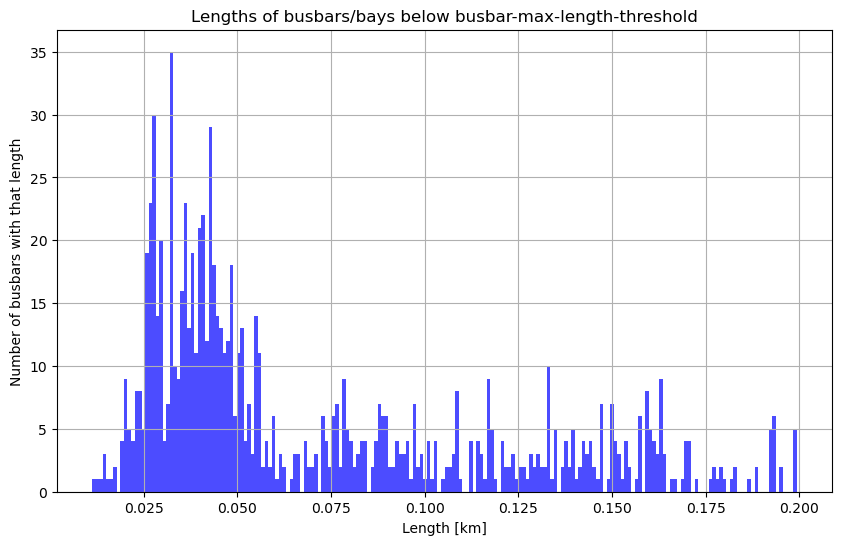

   ... there are 1043 busbars/bays in total
   ... 937 busbars have been deleted
   ... finished! (0.596 seconds) 



In [10]:
data_ways_busbar, data_busbars = delete_busbars(data_ways_all_voltage, bool_options)

In [11]:
data_ways_dc, dc_candidates = count_possible_dc(data_ways_busbar)

Start detecting lines which could be DC lines...
   ... 320 ways could potentially be a DC line.
   ... Please refer to dc_candidates for further checks.
   ... finished! (0.282 seconds) 



In [12]:
data_ways_cables = count_cables(data_ways_dc)

Start counting cables per way...

    cables_per_way  number_of_ways
0               3            2762
1               6            1801
2               1             320
3              12             124
4               9              39
5              18               2
6               4               2
7               8               1
8              20               1
9              11               1
   ... 789 ways with unknown number of cables.
   ... ways with 6 cables will be doubled, ways with 9 cables tripled and ways with 12 cables quadrupled.
   ... finished!


   ... start visualizing all distances in a histogram ...


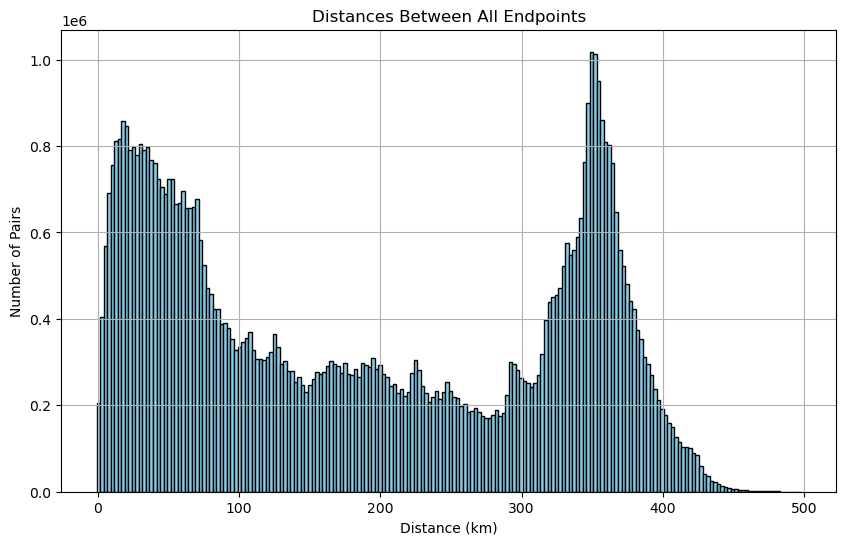

In [13]:
M = calc_distances_between_endpoints(data_ways_cables, bool_options)

Start finding all stacked endnodes...
... 8226 endnodes are stacked!
... finished! (0.541 seconds)

Reprojecting CRS from EPSG:32648 to EPSG:32648.


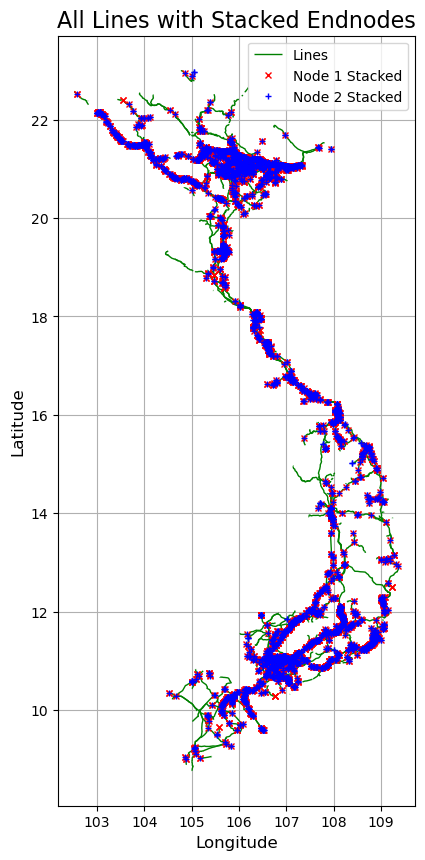

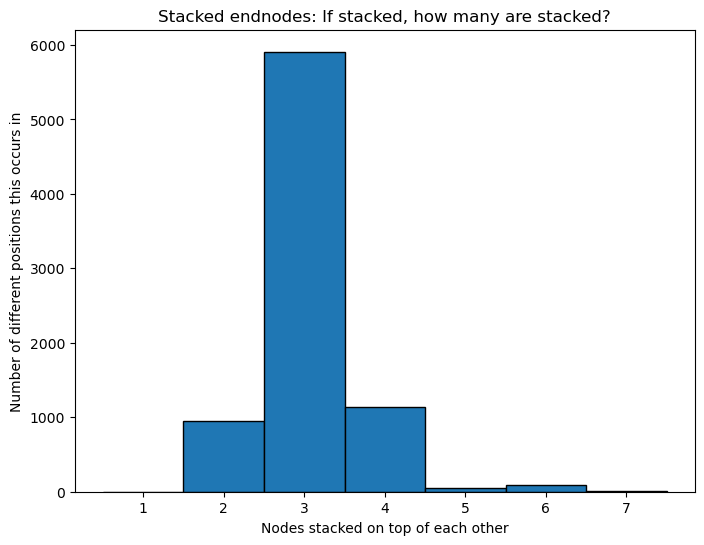

In [14]:
data_ways_stacked, nodes_stacked_pairs = calc_stacked_endnodes(data_ways_cables, M, bool_options)

In [15]:
nodes_stacked_grouped = group_nodes(nodes_stacked_pairs)

Start grouping all pairs from "pairs_input" (may take a few seconds)...
   ... 8226 nodes will be grouped together in 2768 groups,
       with an average of 2.97 nodes per group.
   ... finished! (1.431 seconds)



In [16]:
data_ways_group_stacked_nodes = group_stacked_endnodes(data_ways_cables, nodes_gdf, nodes_stacked_grouped)

Completed updating coordinates for stacked groups.


In [17]:
data_ways_final_coords = add_final_coordinates(data_ways_group_stacked_nodes)

Start adding final coordinates...
... finished!


In [18]:
data_ways_delete, data_singular_ways = delete_singular_ways(data_ways_final_coords, 'ID_node1_final', 'ID_node2_final')

Start deleting ways which have the same endpoints after grouping...
   ... 1322 ways were deleted!
   ... finished! (0.005 seconds)


EPSG:4326 EPSG:4326 EPSG:4326
Start plotting original ways... (takes a few seconds)


/scistor/ivm/mye500/projects/Map2Grid/src/map2grid.py:1354: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "cx-" (-> color='c'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1, label="Busbars")
/scistor/ivm/mye500/projects/Map2Grid/src/map2grid.py:1357: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "cx-" (-> color='c'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'cx-', color="#dec5e3", linewidth=1)
/scistor/ivm/mye500/projects/Map2Grid/src/map2grid.py:1366: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "kx-" (-> color='k'). The keyword argument will take precedence.
  ax.plot(lon, lat, 'kx-', color="#73d2de", linewidth=1, label="Deleted Ways")
/scistor/ivm/mye500/projects/Map2Grid/src/map2grid.py:1369: UserWarning: color is redundantly defined by the 'color' keyword argument an

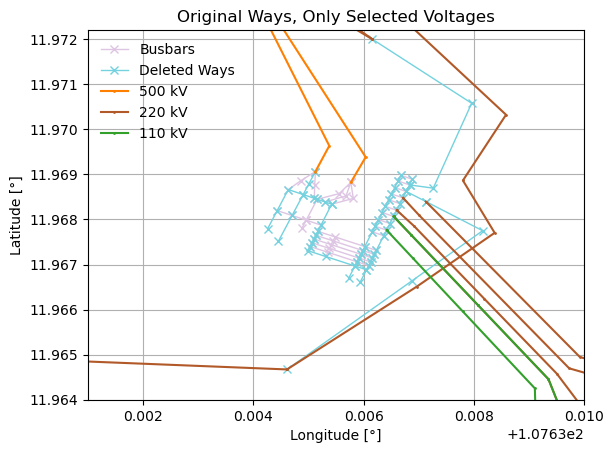

In [19]:
plot_ways_original(data_ways_delete, data_busbars, bool_options, data_singular_ways)

In [20]:
data_ways_clone = add_lineID_clone_ways(data_ways_delete)

Start adding "LineID" and cloning ways...
   ... 1530 ways doubled, 37 tripled, 114 quadrupled.
   ... finished! (2.600 seconds) 



In [21]:
table_lines = fill_line_voltage(data_ways_clone)

In [22]:
table_lines_update = table_lines.dropna(subset=['voltage'])

In [23]:
table_lines_update.head()

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,lat1_grouped,lon2_grouped,lat2_grouped,ID_node1_final,lon1_final,lat1_final,ID_node2_final,lon2_final,lat2_final,LineID
0,153608701,line,110000,NaN,NaN,50,NaN,NaN,NaN,NaN,...,NaN,609979.512105,2.317122e+06,153608703.0,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001a
1,153608701,line,110000,NaN,NaN,50,NaN,NaN,NaN,NaN,...,NaN,609979.512105,2.317122e+06,153608703.0,610714.852695,2.315181e+06,1.000000e+00,609979.512105,2.317122e+06,LINEVN0001b
2,176708144,line,110000,NaN,NaN,50,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,2.0,672622.408581,1.278800e+06,1.197858e+09,651889.179899,1.285444e+06,LINEVN0002
3,241194661,line,220000,NaN,NaN,50,NaN,NaN,NaN,NaN,...,2.315888e+06,684741.069151,2.304331e+06,4.0,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003a
4,241194661,line,220000,NaN,NaN,50,NaN,NaN,NaN,NaN,...,2.315888e+06,684741.069151,2.304331e+06,4.0,682154.017051,2.315888e+06,2.410654e+08,684741.069151,2.304331e+06,LINEVN0003b


In [24]:
output_dir = '../outputs'
export_data(table_lines_update, output_dir)

Start exporting data to Excel files... (may take a few seconds)
INFO: Exported lines to ../outputs/tbl_Lines_VN_500m.xlsx
INFO: Exported Nodes to ../outputs/tbl_Nodes_VN_500m.xlsx
... finished!
